## ECGSYN setup

In [507]:
import neurokit2 as nk
from matplotlib import pyplot as plt
plt.style.use('ggplot')

In [508]:
time = 2
fs = 500

# Raw ECGSYN output — clean ground-truth signal
clean_ecg = nk.ecg_simulate(duration=time,sampling_rate=fs,heart_rate=70,method="ecgsyn")
print(clean_ecg[:3])


[1.08132137 1.06679964 1.02943519]


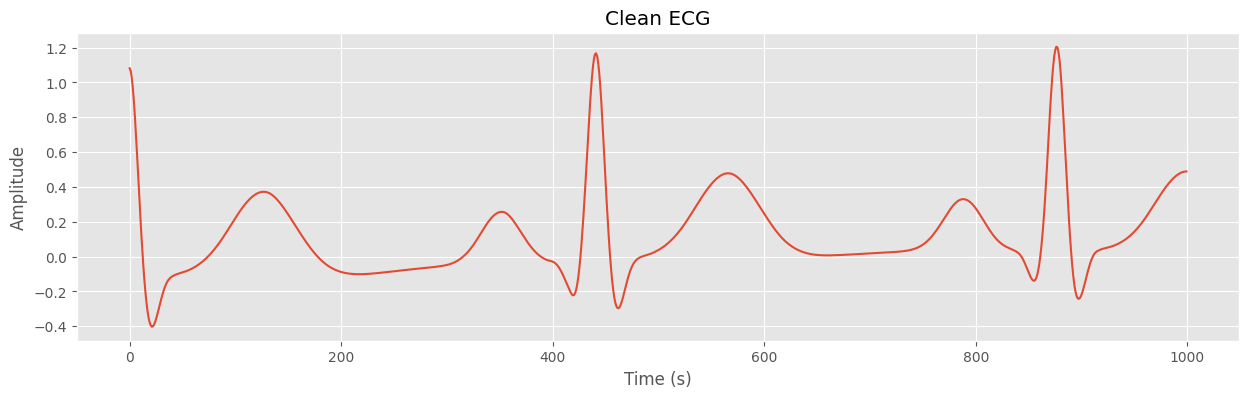

In [509]:
#nk.signal_plot(clean_ecg, sampling_rate=fs, title="Clean ECG")

plt.figure(figsize=(15, 4))
plt.plot(clean_ecg)
plt.title("Clean ECG")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

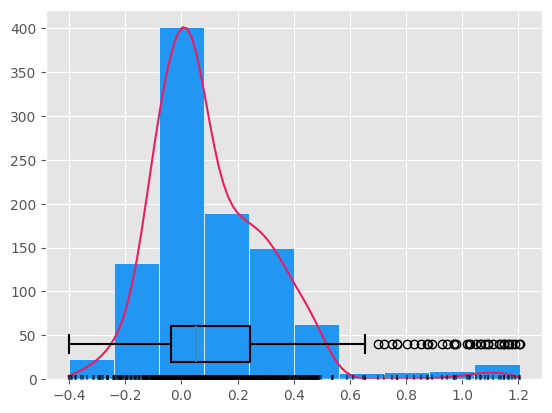

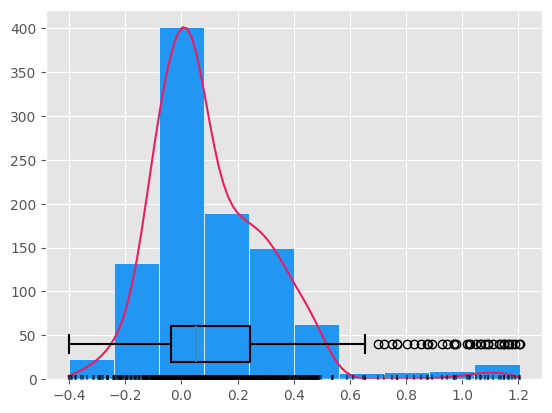

In [510]:
nk.summary_plot(clean_ecg)

## Adding noise to the clean ECG signal

In [511]:
import numpy as np
from numba import njit
from numba import jit

In [512]:
@jit(parallel=True)
def add_noise(sig, snr_db):
    p_sig = np.mean(sig**2)
    p_noise = p_sig / (10**(snr_db/10))
    noise = np.random.normal(0, np.sqrt(p_noise), sig.shape)
    return sig + noise

noisy_ecg = add_noise(clean_ecg, snr_db=1)

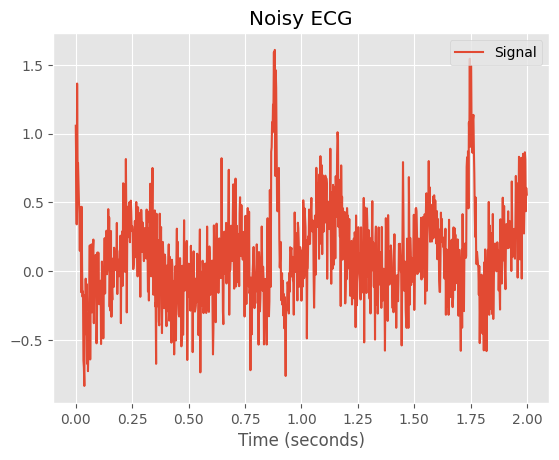

In [513]:
nk.signal_plot(noisy_ecg, sampling_rate=fs, title="Noisy ECG")

## Denoising the signal using a simple filters

In [544]:
def gaussian_smoothing(signal, kernel_size, sigma):
    kernel = np.exp(-0.5 * (np.arange(-kernel_size//2 + 1, kernel_size//2 + 1) / sigma) ** 2)
    kernel /= np.sum(kernel)
    return np.convolve(signal, kernel, mode='same')

def moving_average(signal, window_size):
    return np.convolve(signal, np.ones(window_size)/window_size, mode='same')

def iterative_moving_average(signal, max_window_size):
    smoothed_signal = signal
    for window_size in range(1, max_window_size + 1):
        smoothed_signal = moving_average(smoothed_signal, window_size)
    return smoothed_signal

mv_avg_ecg = noisy_ecg
for i in range(1, 10):
    mv_avg_ecg = moving_average(mv_avg_ecg, window_size=4)

it_mv_avg_ecg = iterative_moving_average(noisy_ecg, max_window_size=10)

gaussian_ecg = noisy_ecg
for i in range(1, 10):
    gaussian_ecg = gaussian_smoothing(gaussian_ecg, kernel_size=5, sigma=1)

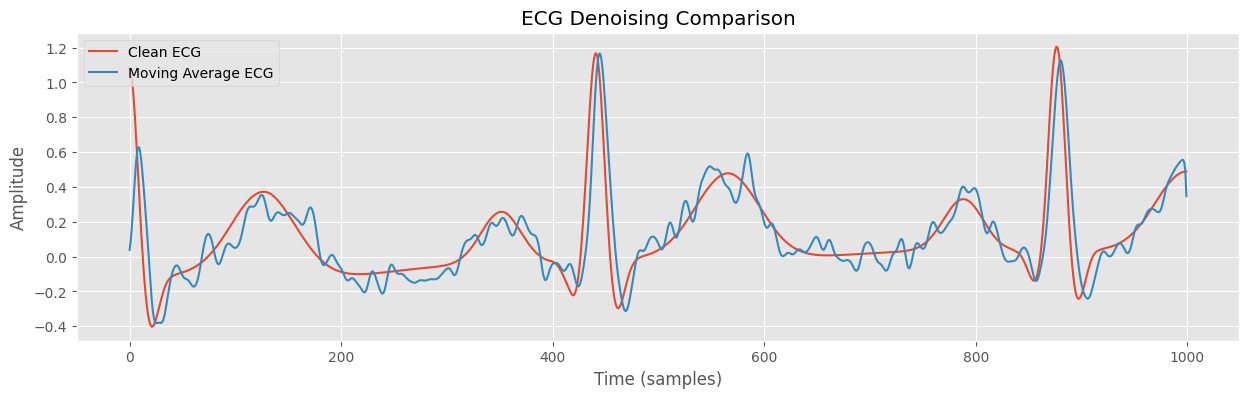

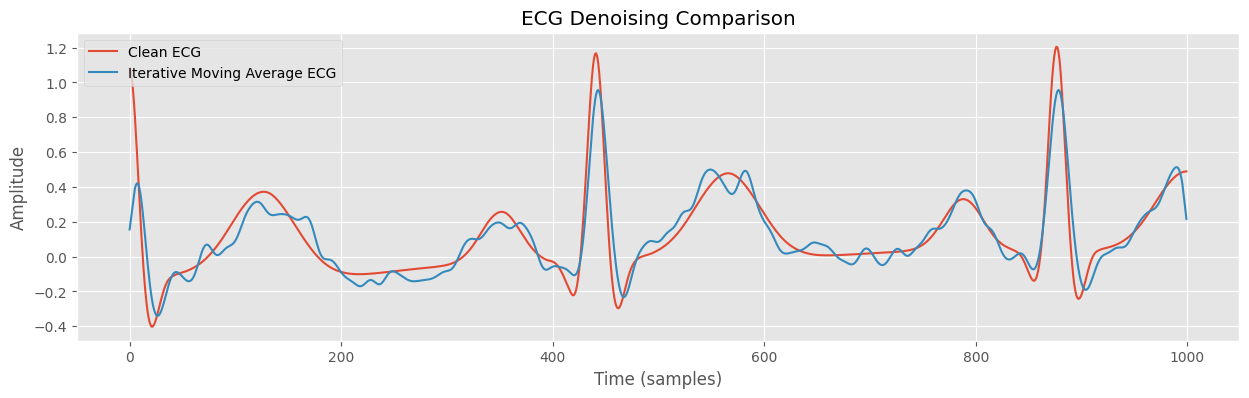

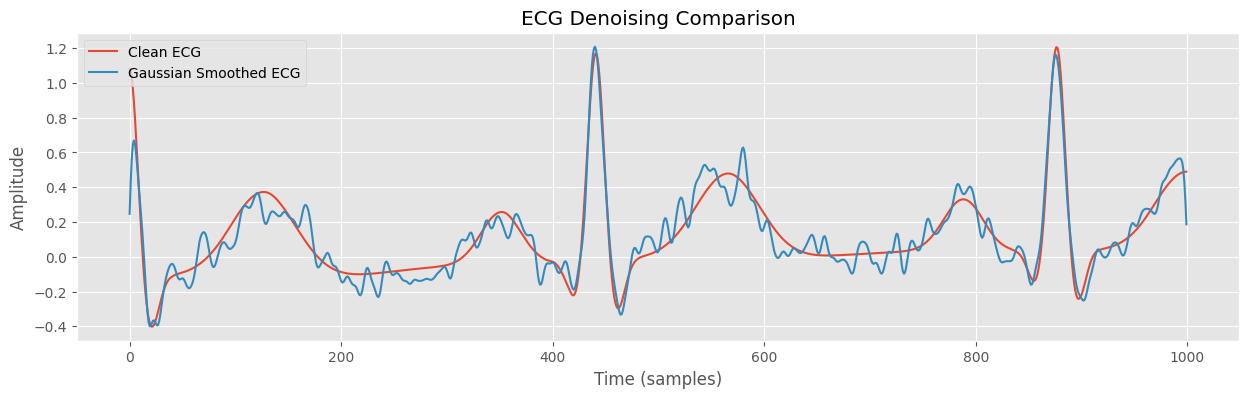

In [545]:
plt.figure(figsize=(15, 4))
plt.plot(clean_ecg, label='Clean ECG')
plt.plot(mv_avg_ecg, label='Moving Average ECG')
plt.legend()
plt.title('ECG Denoising Comparison')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(clean_ecg, label='Clean ECG')
plt.plot(it_mv_avg_ecg, label='Iterative Moving Average ECG')
plt.legend()
plt.title('ECG Denoising Comparison')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(clean_ecg, label='Clean ECG')
plt.plot(gaussian_ecg, label='Gaussian Smoothed ECG')
plt.legend()
plt.title('ECG Denoising Comparison')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()

## Calculating the pulse rate from the signals

In [516]:
@njit(parallel=True)
def pulse(lst, upper=1.0, lower=0.999):
    lst = (np.clip(lst, lower, upper) - 0.7)*100

    upper = (upper - 0.7)*100
    lower = (lower - 0.7)*100

    count = 0
    out = 0
    for i in range(len(lst)-1):
        if lst[i + 1] != lst[i] and (lst[i + 1] in [upper, lower]) and (lst[i] in [upper, lower]):
            count = count + 1

    if count % 2 == 1:
        count = count + 1
    
    return 30 * count / (time)

In [517]:
print(pulse(noisy_ecg))
print(pulse(mv_avg_ecg, upper=0.81, lower=0.8))

300.0
60.0


## Benchmarking the filters using the pulse rate estimation

In [518]:
p = []
p1 = []
p2 = []
p3 = []
p4 = []

for x in range(300,1, -1):
    i = x / 10
    raw_signal = add_noise(clean_ecg, snr_db=i)
    signal = raw_signal
    pulse_rate = pulse(signal)
    p.append(pulse_rate)
    for j in range(1, 6):
        signal = moving_average(signal, window_size=j)
    signal = raw_signal
    pulse_rate = pulse(moving_average(signal, window_size=2), upper=0.81, lower=0.8)
    p1.append(pulse_rate)
    pulse_rate = pulse(iterative_moving_average(signal, max_window_size=6), upper=0.81, lower=0.8)
    p2.append(pulse_rate)
    p3.append(70)

    gaussian_ecg = raw_signal
    for i in range(1, 10):
        gaussian_ecg = gaussian_smoothing(gaussian_ecg, kernel_size=5, sigma=1)
    p4.append(pulse(gaussian_ecg, upper=0.81, lower=0.8))

Estimated std: 65.68849655501293
Denoised std: 30.943378055670255
Iterative Denoised std: 6.751546692144772
Gaussian Smoothed std: 8.127709625850958
True std: 0.0


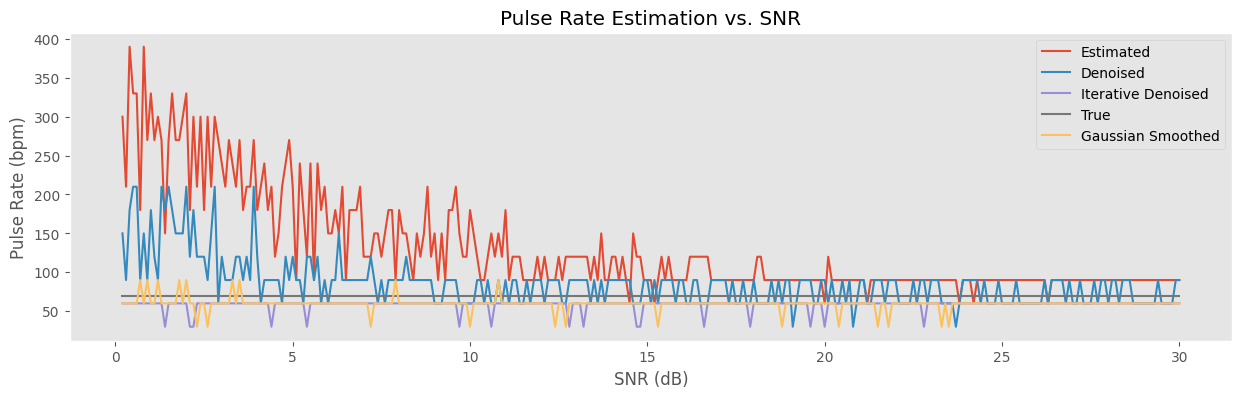

In [520]:
l = [x / 10 for x in range(300,1, -1)]

print(f"Estimated std: {np.std(p)}")
print(f"Denoised std: {np.std(p1)}")
print(f"Iterative Denoised std: {np.std(p2)}")
print(f"Gaussian Smoothed std: {np.std(p4)}")
print(f"True std: {np.std(p3)}")
plt.figure(figsize=(15, 4))
plt.plot(l, p, label='Estimated')
plt.plot(l, p1, label='Denoised')
plt.plot(l, p2, label='Iterative Denoised')
plt.plot(l, p3, label='True')
plt.plot(l, p4, label='Gaussian Smoothed')

plt.xlabel('SNR (dB)')
plt.ylabel('Pulse Rate (bpm)')
plt.title('Pulse Rate Estimation vs. SNR')
plt.grid()
plt.legend()
plt.show()